<a href="https://colab.research.google.com/github/fquinterov/computer_vision_course/blob/main/document_scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Corner detection

Fernando Quintero, M. Eng (c)

Universidad Tecnológica de Bolívar

In this activity we will go through corner detection for a document scanner

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imutils

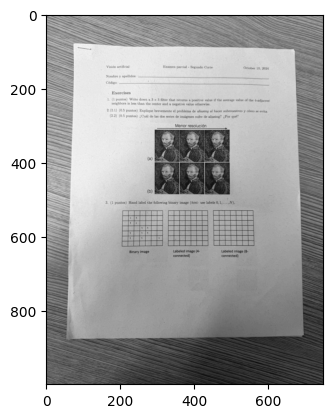

In [ ]:
img = cv2.imread('/content/Image.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap = 'gray')
plt.show()

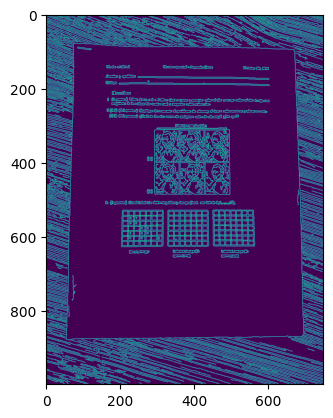

In [ ]:
detail = cv2.detailEnhance(img,sigma_s = 20, sigma_r = 0.15)
gray = cv2.cvtColor(detail,cv2.COLOR_BGR2GRAY) # GRAYSCALE IMAGE
blur = cv2.GaussianBlur(gray,(5,5),0)

# edge detect
edge_image = cv2.Canny(blur,75,200)
plt.imshow(edge_image)

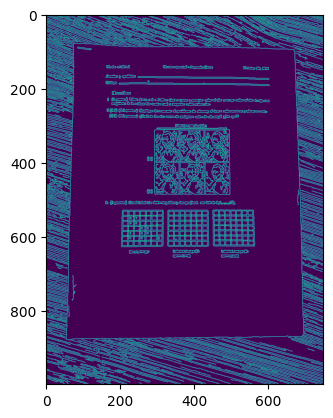

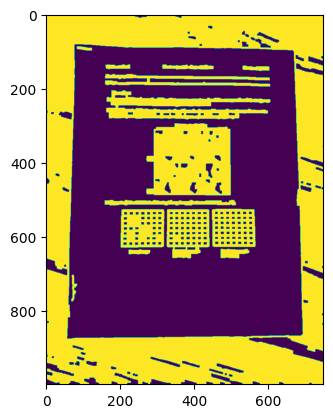

In [ ]:
detail = cv2.detailEnhance(img,sigma_s = 20, sigma_r = 0.15)
gray = cv2.cvtColor(detail,cv2.COLOR_BGR2GRAY) # GRAYSCALE IMAGE
blur = cv2.GaussianBlur(gray,(5,5),0)

# edge detect
edge_image = cv2.Canny(blur,75,200)

# morphological transform
kernel = np.ones((5,5),np.uint8)
dilate = cv2.dilate(edge_image,kernel,iterations=1)
closing = cv2.morphologyEx(dilate,cv2.MORPH_CLOSE,kernel)

plt.imshow(edge_image)
plt.show()

plt.imshow(closing)
plt.show()

array([[[128, 127, 129],
        [125, 124, 126],
        [119, 118, 120],
        ...,
        [123, 122, 124],
        [120, 119, 121],
        [119, 119, 119]],

       [[153, 152, 154],
        [145, 144, 146],
        [131, 130, 132],
        ...,
        [142, 141, 143],
        [136, 135, 137],
        [133, 133, 133]],

       [[168, 167, 169],
        [167, 166, 168],
        [161, 160, 162],
        ...,
        [154, 153, 155],
        [155, 154, 156],
        [153, 152, 154]],

       ...,

       [[108, 107, 109],
        [106, 105, 107],
        [107, 106, 108],
        ...,
        [ 68,  70,  71],
        [ 64,  66,  67],
        [ 61,  63,  64]],

       [[101, 100, 102],
        [ 98,  97,  99],
        [ 96,  95,  97],
        ...,
        [ 79,  81,  82],
        [ 78,  80,  81],
        [ 76,  78,  79]],

       [[116, 115, 117],
        [112, 111, 113],
        [103, 102, 104],
        ...,
        [ 76,  78,  79],
        [ 77,  79,  80],
        [ 78,  78,  78]]], dtype=uint8)
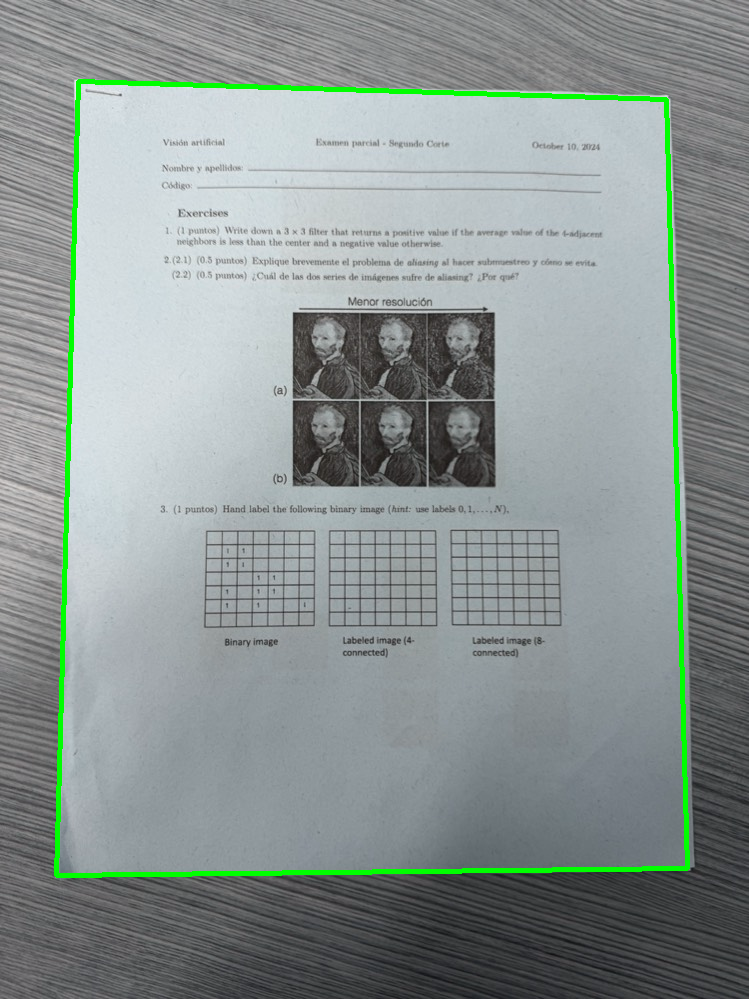

In [ ]:
# find the contours
contours , hire = cv2.findContours(closing, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)
for contour in contours:
    perimeter = cv2.arcLength(contour,True)
    corners = cv2.approxPolyDP(contour,0.02*perimeter, True)

    if len(corners) == 4:
        four_points = np.squeeze(corners)
        break

cv2.drawContours(img,[four_points],-1,(0,255,0),3)

In [ ]:
four_points

array([[ 78,  81],
       [666,  99],
       [687, 868],
       [ 56, 875]], dtype=int32)

In [ ]:
four_points[:,0]

array([ 78, 666, 687,  56], dtype=int32)

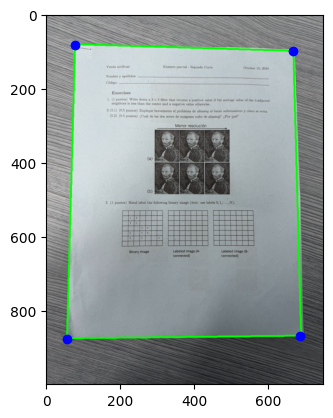

In [ ]:
plt.imshow(img)
plt.plot(four_points[:,0],four_points[:,1], 'bo')
plt.show()